In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

FileNotFoundError: [Errno 2] No such file or directory: '../../../../info.json'

In [ ]:
TEST_NUM = OPTIONS['dynamic_tests'].get('reference')
PATH     = f'files/test{TEST_NUM}'
print(PATH)

INFO = json.loads(open(f'{PATH}/info.json', 'r', encoding='utf-8').read())
INFO

files/test1


{'variable': 'roll', 'limits': [15, 60]}

In [ ]:
TARGET_VAR  = INFO.get('variable')
TEST_VAR    = OPTIONS.get('test')
TARGET_TIME = tuple(INFO.get('limits'))

# IMPORTANDO DADOS

In [ ]:
df = pd.read_csv(f'{PATH}/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,az,time,roll,q1,sample_time,q3,q0,la_pos_mon_d,wx,wz,ay,pitch,yaw,q2,ax,wy
0,-0.004655,0.000000,-0.002167,-0.001074,905000000.0,-0.003748,1.0000,0.0,-0.02663,-0.033190,-9.799,0.005417,-0.007499,0.002714,-0.015650,0.007875
1,-0.206200,0.023646,-0.001430,-0.000709,5000000.0,-0.003946,1.0000,0.0,0.02602,0.009223,-9.776,0.003464,-0.007892,0.001736,0.072450,-0.032990
2,-0.121400,0.120642,0.002106,0.001052,105000000.0,-0.002717,1.0000,0.0,0.03110,0.025450,-9.790,-0.000706,-0.005432,-0.000356,0.013370,-0.035890
3,0.106200,0.227156,0.001476,0.000739,205000000.0,-0.002987,1.0000,0.0,-0.01863,-0.019050,-9.788,-0.000889,-0.005970,-0.000448,-0.062140,0.010090
4,0.030270,0.323213,-0.000316,-0.000158,305000000.0,-0.004627,1.0000,0.0,-0.01509,-0.031720,-9.794,0.000278,-0.009250,0.000141,-0.018350,0.006354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,-0.227300,63.628676,1.389000,0.088980,605000000.0,0.641100,-0.3988,10.0,0.05193,0.018920,-9.799,-0.684500,-2.605000,0.649600,0.005302,0.030090
638,-0.213300,63.736628,1.390000,0.087490,705000000.0,0.639400,-0.4008,10.0,0.04650,0.019910,-9.776,-0.685600,-2.600000,0.650300,-0.018550,0.038110
639,-0.210900,63.829486,1.392000,0.086110,805000000.0,0.637600,-0.4029,10.0,0.04815,0.021100,-9.784,-0.687100,-2.595000,0.651000,-0.045310,0.036670
640,-0.218800,63.925292,1.394000,0.084510,905000000.0,0.635700,-0.4047,10.0,0.05412,0.017540,-9.798,-0.688200,-2.591000,0.651900,-0.047680,0.032520


- Convertendo pra radianos

In [ ]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,az,time,roll,q1,sample_time,q3,q0,la_pos_mon_d,wx,wz,ay,pitch,yaw,q2,ax,wy
0,-0.004655,0.000000,-0.124160,-0.001074,905000000.0,-0.003748,1.0000,0.0,-1.525787,-1.901647,-9.799,0.310371,-0.429661,0.002714,-0.015650,0.451204
1,-0.206200,0.023646,-0.081933,-0.000709,5000000.0,-0.003946,1.0000,0.0,1.490836,0.528439,-9.776,0.198473,-0.452178,0.001736,0.072450,-1.890188
2,-0.121400,0.120642,0.120665,0.001052,105000000.0,-0.002717,1.0000,0.0,1.781899,1.458178,-9.790,-0.040428,-0.311231,-0.000356,0.013370,-2.056346
3,0.106200,0.227156,0.084569,0.000739,205000000.0,-0.002987,1.0000,0.0,-1.067420,-1.091485,-9.788,-0.050913,-0.342056,-0.000448,-0.062140,0.578114
4,0.030270,0.323213,-0.018134,-0.000158,305000000.0,-0.004627,1.0000,0.0,-0.864593,-1.817422,-9.794,0.015951,-0.529986,0.000141,-0.018350,0.364057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,-0.227300,63.628676,79.583838,0.088980,605000000.0,0.641100,-0.3988,10.0,2.975370,1.084036,-9.799,-39.218961,-149.255506,0.649600,0.005302,1.724030
638,-0.213300,63.736628,79.641134,0.087490,705000000.0,0.639400,-0.4008,10.0,2.664254,1.140759,-9.776,-39.281986,-148.969027,0.650300,-0.018550,2.183542
639,-0.210900,63.829486,79.755725,0.086110,805000000.0,0.637600,-0.4029,10.0,2.758792,1.208941,-9.784,-39.367930,-148.682548,0.651000,-0.045310,2.101036
640,-0.218800,63.925292,79.870317,0.084510,905000000.0,0.635700,-0.4047,10.0,3.100848,1.004968,-9.798,-39.430955,-148.453365,0.651900,-0.047680,1.863259


# VISUALIZAÇÃO DE VARIÁVEIS

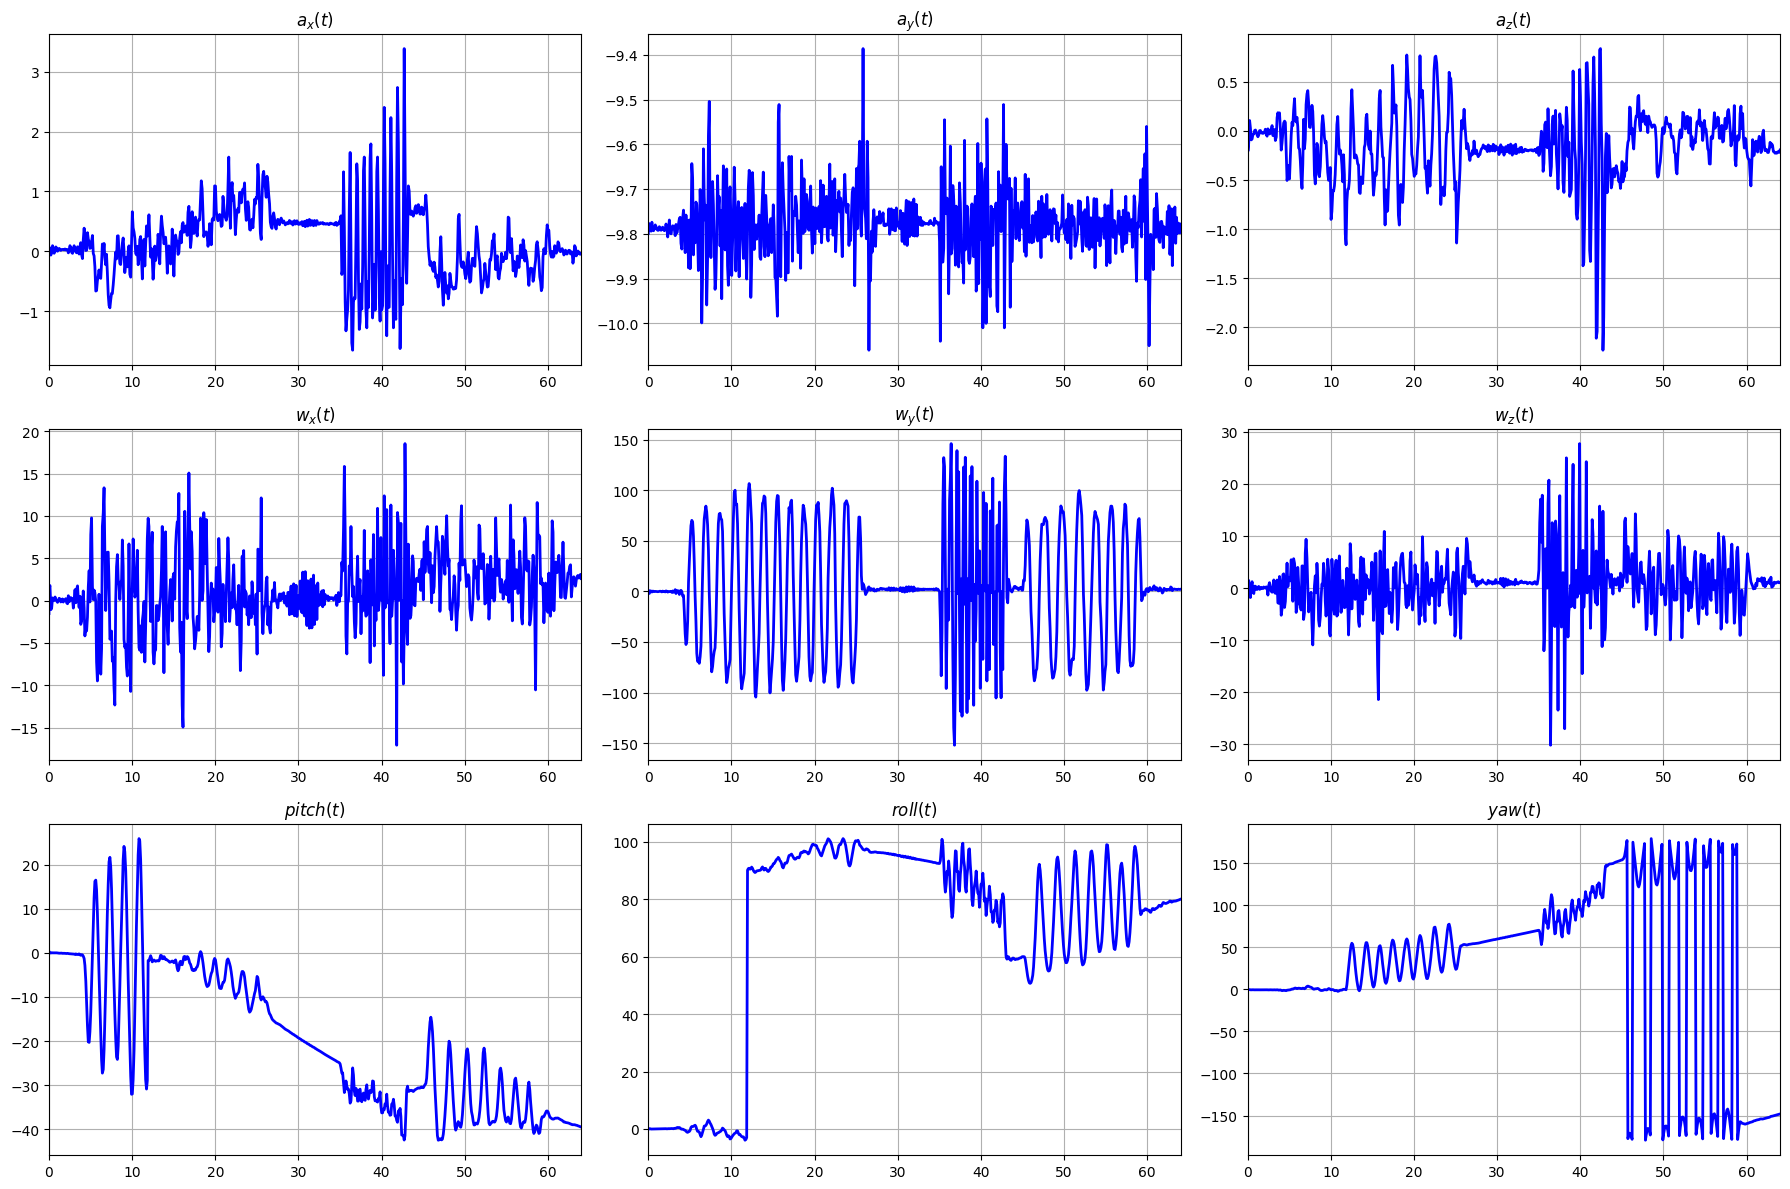

In [ ]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# FILTRANDO POR VARIAVEL

In [ ]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

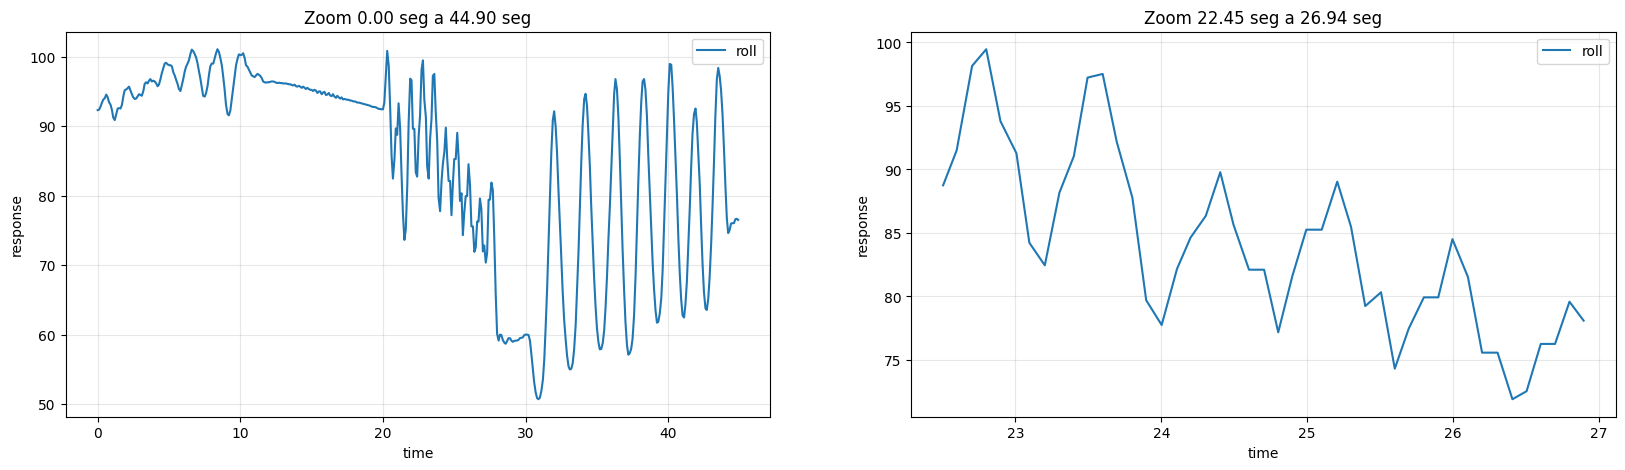

In [ ]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [ ]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col != 'time'})
df

,ref_az,time,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy
151,-0.44210,0.000000,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931
152,-0.65480,0.099214,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984
153,-0.55400,0.204345,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608
154,-0.42470,0.299682,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499
155,-0.45180,0.404275,93.850487,0.7237,405000000.0,0.13380,0.6698,0.08842,9.304835,6.669229,-9.946,-3.566662,18.787286,0.098180,0.16980,89.037641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,0.17720,44.503745,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727
597,-0.06857,44.598816,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458
598,-0.17420,44.704490,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749
599,-0.07313,44.802879,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920


In [ ]:
os.makedirs(f'output', exist_ok=True)
INFO = {}

with open('output/info.json', 'w') as file:
    file.write(json.dumps(INFO, indent=4))

df.to_csv('output/data.csv', index=None)